# Lib


In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

In [19]:
pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Data


In [20]:
df = pd.read_csv("../data/clean/data2.csv", parse_dates=["date"])
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Shape:", df.shape)
df.head()

Shape: (306000, 36)


,location_id,location_name,date,pm10,pm2_5,carbon_monoxide,sulphur_dioxide,ozone,nitrogen_dioxide,aerosol_optical_depth,dust,us_aqi_pm2_5,us_aqi_pm10,us_aqi_nitrogen_dioxide,us_aqi_carbon_monoxide,us_aqi_ozone,us_aqi_sulphur_dioxide,us_aqi,temperature_2m,relative_humidity_2m,rain,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,weather_code,sunshine_duration,boundary_layer_height,dew_point_2m,is_day,aqi_category,hour,month,day_of_week,is_weekend,season
0,1566083,Ho Chi Minh City,2023-01-01 00:00:00,95.0,65.0,993.0,37.50,25.0,84.40,0.29,0.0,133.11458,58.687496,41.568165,9.687199,24.002783,20.447111,133.11458,23.85,61.484700,0.0,1013.40027,100.0,11.304229,9.162280,3.0,0.0,70.0,16.0,0.0,unhealthy for sensitive groups,0,1,Sunday,True,dry
1,1566083,Ho Chi Minh City,2023-01-01 01:00:00,86.1,59.0,846.0,30.75,28.0,70.25,0.25,0.0,132.65625,58.570840,34.599094,10.109903,18.784786,16.766632,132.65625,23.30,62.749770,0.0,1013.19920,100.0,10.739833,13.570457,3.0,0.0,80.0,15.8,0.0,unhealthy for sensitive groups,1,1,Sunday,True,dry
2,1566083,Ho Chi Minh City,2023-01-01 02:00:00,83.4,57.0,821.0,28.90,26.0,65.80,0.24,0.0,131.73958,58.312500,32.407406,10.200483,14.784323,15.757906,131.73958,22.75,64.459640,0.0,1012.69824,100.0,8.287822,2.489499,3.0,0.0,105.0,15.7,0.0,unhealthy for sensitive groups,2,1,Sunday,True,dry
3,1566083,Ho Chi Minh City,2023-01-01 03:00:00,80.1,54.8,834.0,28.45,22.0,63.95,0.24,0.0,130.64583,58.002083,31.496256,10.055555,12.117347,15.512541,130.64583,22.25,65.602090,0.0,1012.29730,100.0,8.669949,4.763556,3.0,0.0,135.0,15.5,0.0,unhealthy for sensitive groups,3,1,Sunday,True,dry
4,1566083,Ho Chi Minh City,2023-01-01 04:00:00,69.4,47.5,838.0,27.20,20.0,60.10,0.23,0.0,129.43752,57.658333,29.600079,9.801933,11.421614,14.830973,129.43752,21.95,66.812325,0.0,1012.19680,100.0,7.928178,357.397500,3.0,0.0,145.0,15.5,0.0,unhealthy for sensitive groups,4,1,Sunday,True,dry


# Matrix correlation


In [21]:
weather_numeric_cols = [
    "temperature_2m",
    "relative_humidity_2m",
    "rain",
    "surface_pressure",
    "cloud_cover",
    "wind_speed_10m",
    "wind_direction_10m",
    "sunshine_duration",
    "boundary_layer_height",
    "dew_point_2m",
]

## Between weather


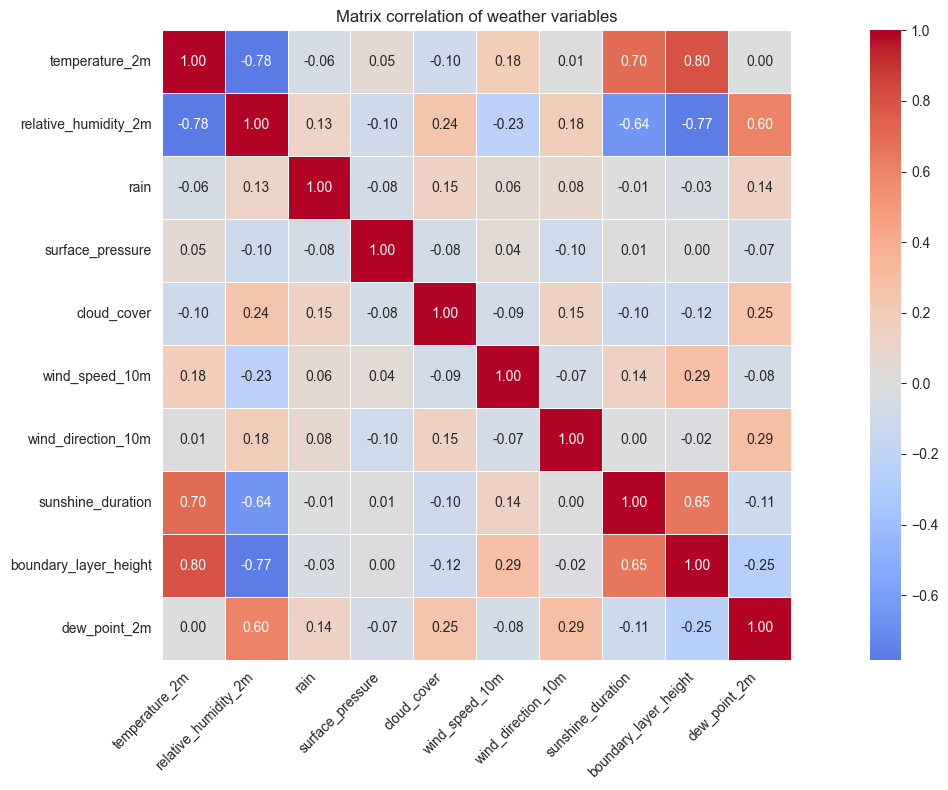

In [22]:
plt.figure(figsize=(16, 8))
corr_weather = df[weather_numeric_cols].corr()
sns.heatmap(
    corr_weather,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Matrix correlation of weather variables")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [23]:
threshold = 0.7
corr_pairs = []
for i in range(len(corr_weather.columns)):
    for j in range(i + 1, len(corr_weather.columns)):
        r = corr_weather.iloc[i, j]
        if abs(r) > threshold:
            corr_pairs.append(
                (corr_weather.columns[i], corr_weather.columns[j], round(r, 3))
            )

corr_pairs = pd.DataFrame(
    corr_pairs, columns=["variable 1", "variable 2", "correlation"]
)
corr_pairs = corr_pairs.sort_values(by="correlation", ascending=False)
corr_pairs

,variable 1,variable 2,correlation
1,temperature_2m,boundary_layer_height,0.802
2,relative_humidity_2m,boundary_layer_height,-0.773
0,temperature_2m,relative_humidity_2m,-0.784


## Between aqi


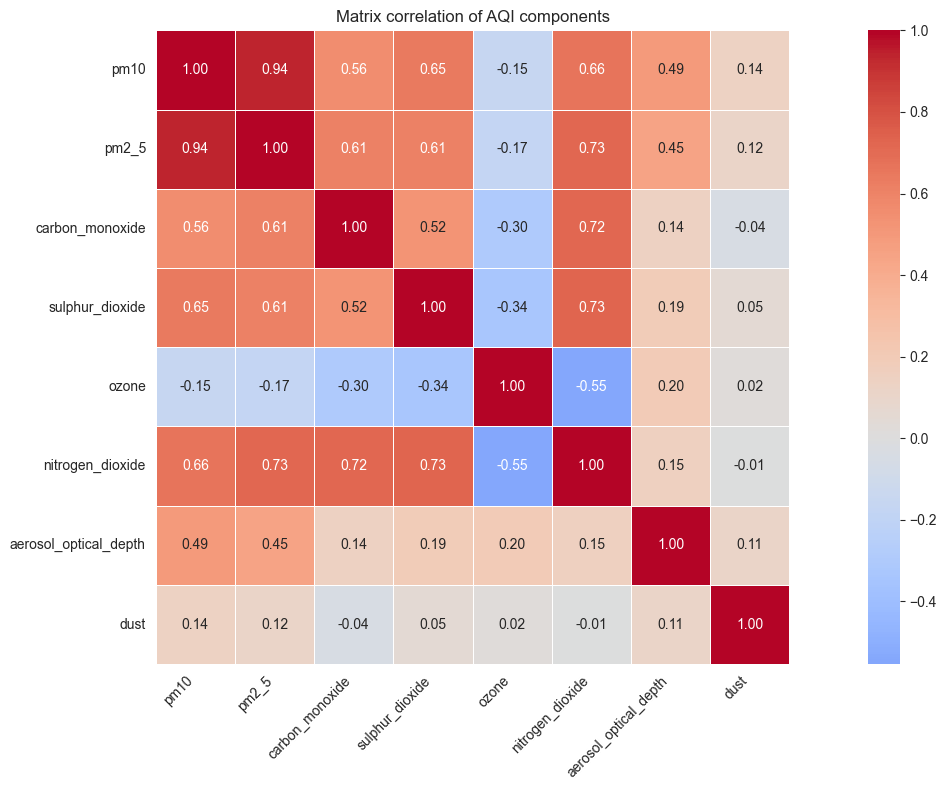

In [24]:
aqi_component_cols = [
    "pm10",
    "pm2_5",
    "carbon_monoxide",
    "sulphur_dioxide",
    "ozone",
    "nitrogen_dioxide",
    "aerosol_optical_depth",
    "dust",
]

plt.figure(figsize=(16, 8))
corr_aqi = df[aqi_component_cols].corr()
sns.heatmap(
    corr_aqi,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
)
plt.title("Matrix correlation of AQI components")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Interaction analysis by AQI category


In [25]:
category_order = df["aqi_category"].unique().tolist()
category_order

['unhealthy for sensitive groups',
 'moderate',
 'good',
 'unhealthy',
 'very unhealthful']

## Scatter Plot: wind speed vs boundary layer height


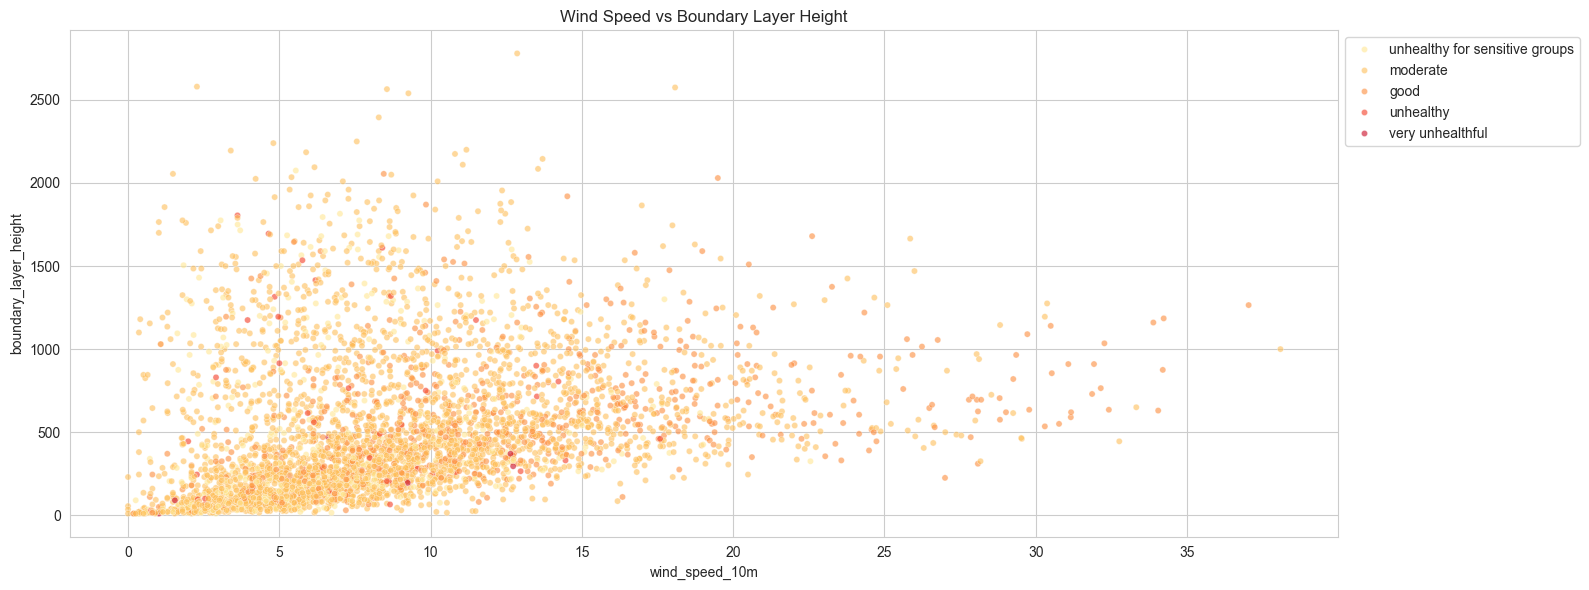

In [26]:
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

plt.figure(figsize=(16, 6))
sns.scatterplot(
    data=sample_df,
    x="wind_speed_10m",
    y="boundary_layer_height",
    hue="aqi_category",
    hue_order=category_order,
    palette="YlOrRd",
    alpha=0.6,
    s=20,
)
plt.title("Wind Speed vs Boundary Layer Height")
plt.legend(bbox_to_anchor=(1, 1), loc="upper left")
plt.tight_layout()
plt.show()

## Pairplot of the most important weather variables


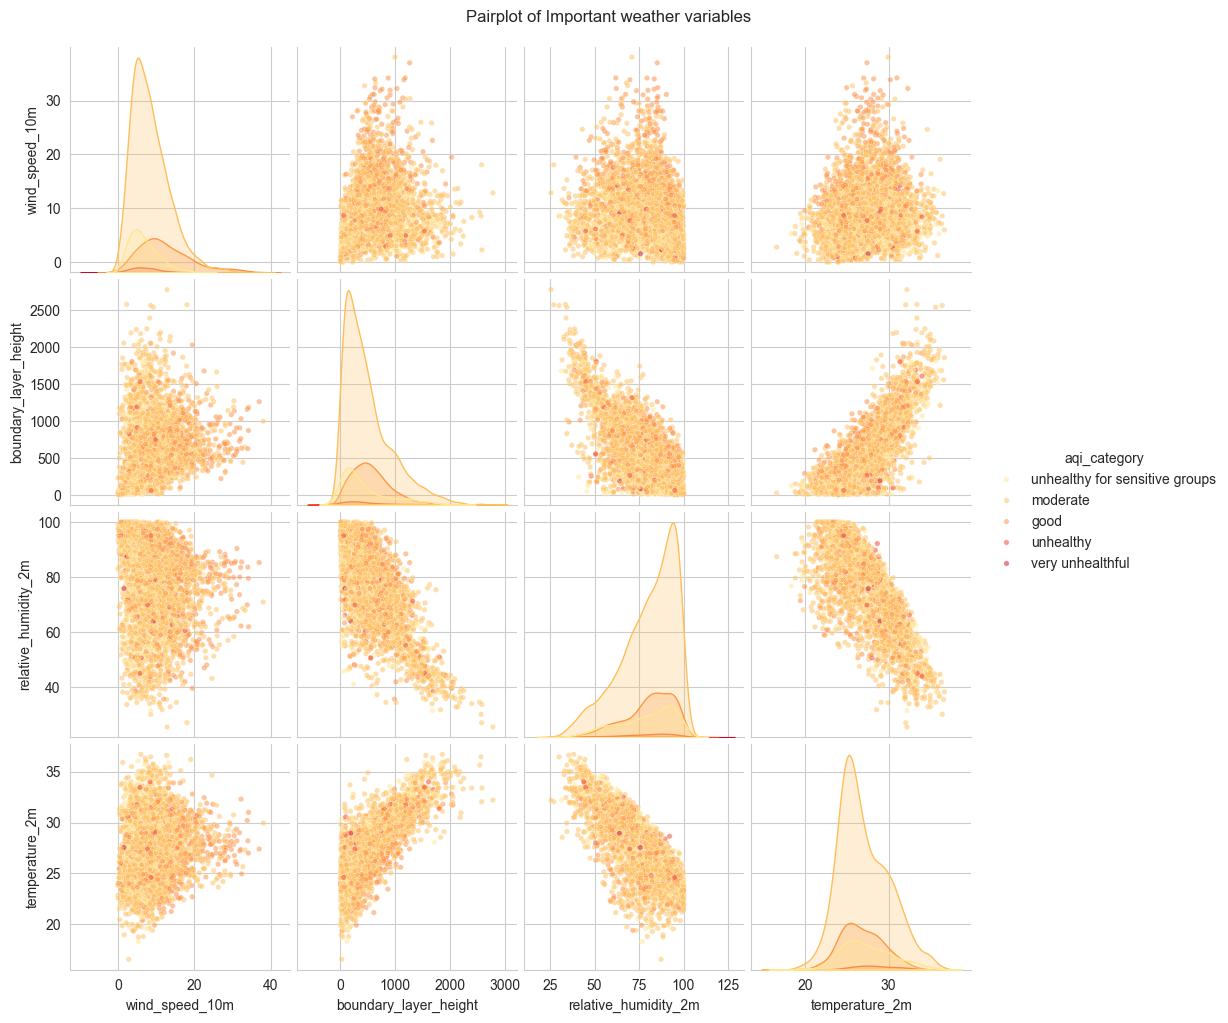

In [27]:
top_vars = [
    "wind_speed_10m",
    "boundary_layer_height",
    "relative_humidity_2m",
    "temperature_2m",
]

pairplot_df = sample_df[top_vars + ["aqi_category"]].dropna()

g = sns.pairplot(
    pairplot_df,
    hue="aqi_category",
    hue_order=category_order,
    palette="YlOrRd",
    diag_kind="kde",
    plot_kws={"alpha": 0.5, "s": 15},
)
g.figure.suptitle("Pairplot of Important weather variables", y=1.02)
plt.show()

### Heatmap: Average AQI by (hour vs season)


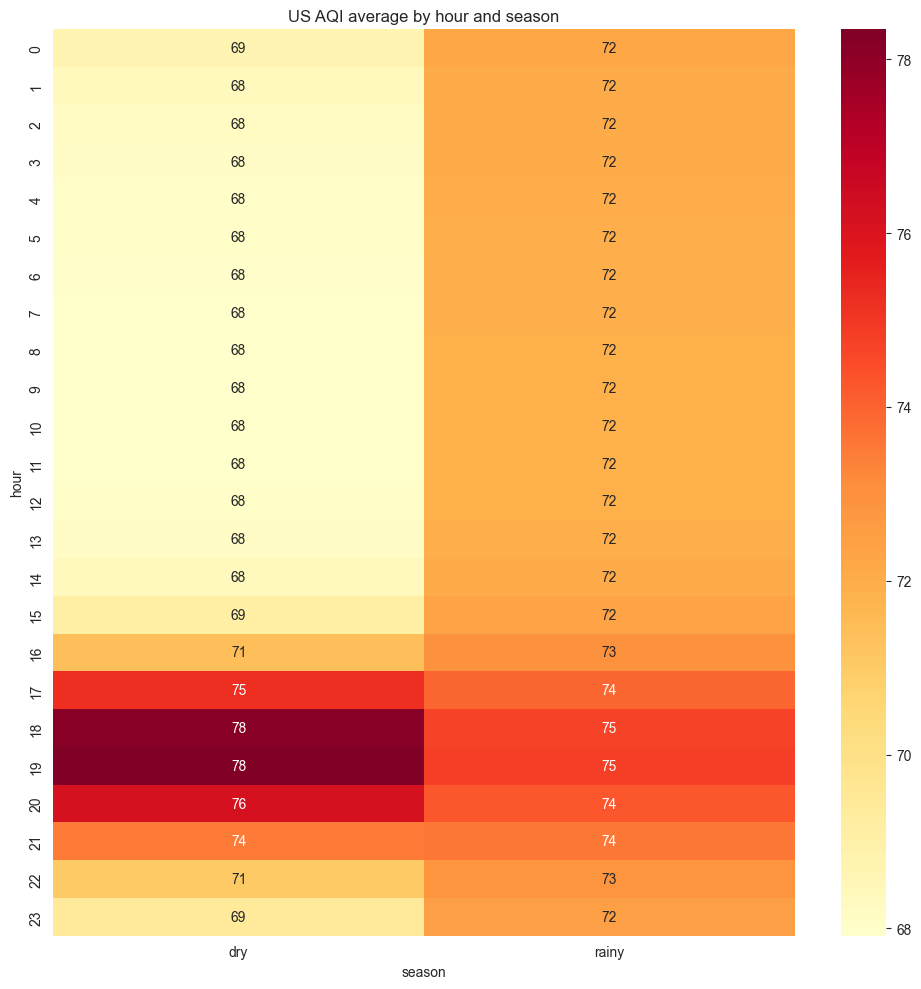

In [28]:
pivot_hour_season = df.pivot_table(
    values="us_aqi", index="hour", columns="season", aggfunc="mean"
)

plt.figure(figsize=(10, 10))
sns.heatmap(pivot_hour_season, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("US AQI average by hour and season")
plt.tight_layout()
plt.show()

### Heatmap: Average AQI by (location vs aqi)


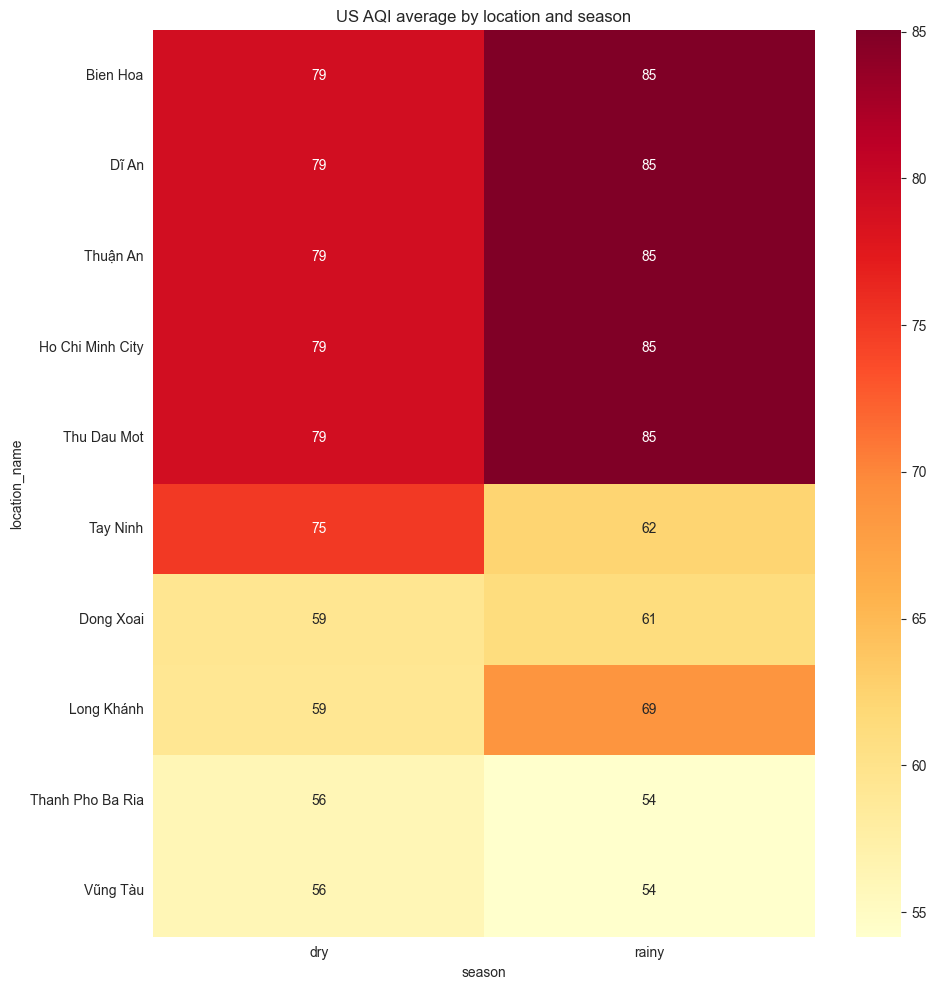

In [29]:
pivot_loc_season = df.pivot_table(
    values="us_aqi", index="location_name", columns="season", aggfunc="mean"
)
pivot_loc_season = pivot_loc_season.sort_values("dry", ascending=False)

plt.figure(figsize=(10, 10))
sns.heatmap(pivot_loc_season, annot=True, fmt=".0f", cmap="YlOrRd")
plt.title("US AQI average by location and season")
plt.tight_layout()
plt.show()